# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Noah Demmenie
* Username: ndemmenie
* Student number: S6294588
* Group (AS1, etc.): AS3

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

Error propagation for: $$g = \frac{4\pi^2 L}{T^2}$$

The measured quantities are:

$$L = 1.00 \pm 0.01 \; m$$

$$T = 2.01 \pm 0.02 \; s$$

The function is:

$$g(L,T) = \frac{4\pi^2 L}{T^2}$$

Using first-order Taylor error propagation:

$$\sigma_g^2 = \left(\frac{\partial g}{\partial L}\right)^2\sigma_L^2 + \left(\frac{\partial g}{\partial T}\right)^2\sigma_T^2$$

Partial derivatives:

$$\frac{\partial g}{\partial L} = \frac{4\pi^2}{T^2}$$

$$\frac{\partial g}{\partial T} = -\frac{8\pi^2 L}{T^3}$$

Insert into propagation formula:

$$\sigma_g^2 = \left(\frac{4\pi^2}{T^2}\right)^2 \sigma_L^2 + \left(\frac{8\pi^2 L}{T^3}\right)^2\sigma_T^2$$

In [2]:
import numpy as np

# Define variables

L = 1.00
T = 2.01
sigma_L = 0.01
sigma_T = 0.02

# Compute g value with error (Taylor)

g_value_taylor = (4 * np.pi**2 * L) / T**2
sigma_g_taylor = np.sqrt(((4 * np.pi**2 / T**2) * sigma_L)**2 + ((8 * np.pi**2 * L / T**3) * sigma_T)**2)

# Compute distributions with all their g values (Monte Carlo)

L_distr = np.random.normal(1.00, 0.01, 100000)
T_distr = np.random.normal(2.01, 0.02, 100000)
g_values_distr = (4 * np.pi**2 * L_distr) / T_distr**2

# Compute final g value with error (Monte Carlo)

g_value_mc = np.mean(g_values_distr)
sigma_g_mc = np.std(g_values_distr)

print(f"g computed with Taylor = {g_value_taylor:.1f} \u00B1 {sigma_g_taylor:.1f} m/s^2")
print(f"g computed with Monte Carlo = {g_value_mc:.1f} \u00B1 {sigma_g_mc:.1f} m/s^2")

g computed with Taylor = 9.8 ± 0.2 m/s^2
g computed with Monte Carlo = 9.8 ± 0.2 m/s^2


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [4]:
import numpy as np

# Input coefficients and print equation

a = float(input("Enter a: "))
b = float(input("Enter b: "))
c = float(input("Enter c: "))

print(f"f(x) = {a}x^2 + {b}x + {c} = 0")

# Define function for prove

f = lambda x: a*x**2 + b*x + c

# Compute roots

D = np.array(b**2 - 4*a*c, dtype=complex)

if D == 0:
    x = (-b+np.sqrt(D))/(2*a)
    print(f"The solution is x = {x}")
    print(f"Proof: f(x) = {f(x)}")
else:
    x1 = (-b+np.sqrt(D))/(2*a)
    x2 = (-b-np.sqrt(D))/(2*a)
    print(f"The solutions are x1 = {x1} and x2 = {x2}")
    print(f"Proof: f(x1) = {f(x1)} and f(x2) = {f(x2)}")

Enter a:  2
Enter b:  2
Enter c:  2


f(x) = 2.0x^2 + 2.0x + 2.0 = 0
The solutions are x1 = (-0.5+0.8660254037844386j) and x2 = (-0.5-0.8660254037844386j)
Proof: f(x1) = (2.220446049250313e-16+0j) and f(x2) = (2.220446049250313e-16+0j)


In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

**1,2,3,4,5,6:**

Area from 0 to 2.5 = 1.9769788548675902
Area from -inf to inf with quad() = 5.013256549262001
Area from -inf to inf with formula = 5.0132565492620005


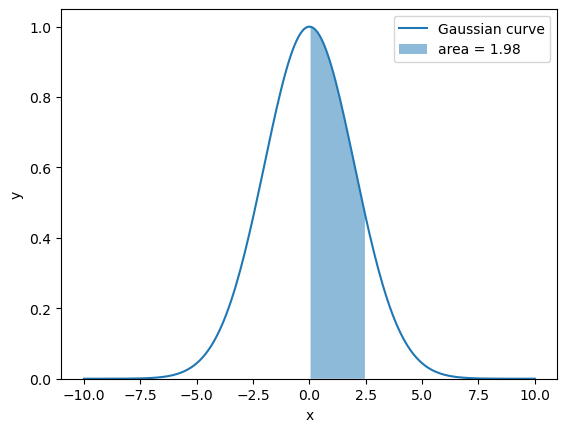

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# Define gauss function

def gauss(x, A, x0, sigma, z0):
   return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

# Compute areas with quad()

area1 = integrate.quad(gauss, 0, 2.5, args=(1.0, 0.0, 2.0, 0.0))[0]
area2 = integrate.quad(gauss, -np.inf, np.inf, args=(1.0, 0.0, 2.0, 0.0))[0]

# Compute area with formula

A = 1.0
sigma = 2.0
area3 = A * sigma * np.sqrt(2*np.pi)

print(f"Area from 0 to 2.5 = {area1}")
print(f"Area from -inf to inf with quad() = {area2}")
print(f"Area from -inf to inf with formula = {area3}")

# Plot everything

x = np.linspace(-10, 10, 200)
plt.plot(x, gauss(x, 1.0, 0.0, 2.0, 0.0), label = 'Gaussian curve')
plt.fill_between(x, gauss(x, 1.0, 0.0, 2.0, 0.0), where=(x >= 0) & (x <= 2.5), alpha=0.5, label = f'area = {area1:.2f}')
plt.ylim(0, None)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

**7,8:**

Enter A:  2
Enter x0:  0
Enter sigma:  2
Enter z0:  2
Enter lower bound for integral:  0
Enter upper bound for integral:  5


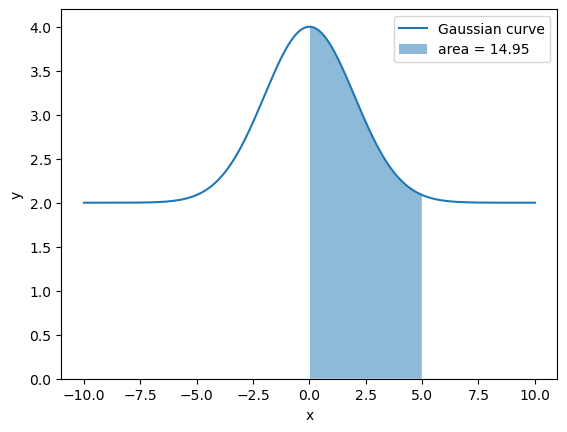

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# Define gauss function

def gauss(x, A, x0, sigma, z0):
   return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

# Users input

A = float(input("Enter A: "))
x0 = float(input("Enter x0: "))
sigma = float(input("Enter sigma: "))
z0 = float(input("Enter z0: "))
a = float(input("Enter lower bound for integral: "))
b = float(input("Enter upper bound for integral: "))

# Compute area

area = integrate.quad(gauss, a, b, args=(A, x0, sigma, z0))[0]

# Compute reasonable linspace

xmin_plot = min(a, x0 - 5*sigma)
xmax_plot = max(b, x0 + 5*sigma)
x_plot = np.linspace(xmin_plot, xmax_plot, 400)

# Plot everything

plt.plot(x_plot, gauss(x_plot, A, x0, sigma, z0), label = 'Gaussian curve')
plt.fill_between(x_plot, gauss(x_plot, A, x0, sigma, z0), 0, where=(x_plot >= a) & (x_plot <= b), alpha=0.5, label = f'area = {area:.2f}')
plt.xlabel('x')
plt.ylim(0, None)
plt.ylabel('y')
plt.legend()
plt.show()

Github: https://github.com/noahdemmenie/PROGNUM-repo

Generated plot from gaussarea.py script with:

A = 2

x0 = 0

sigma = 2

z0 = 2

Integral from 0 to 5

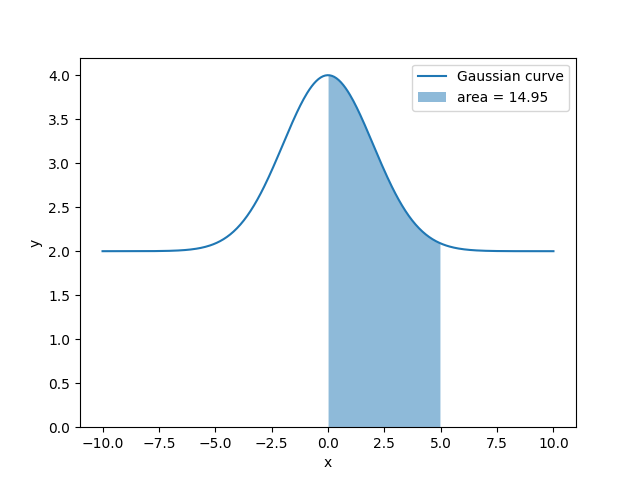

In [8]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

Github: https://github.com/noahdemmenie/PROGNUM-repo

In [9]:
from numpy import sin, cos, exp, pi
import numpy as np
from scipy import integrate

# Users input function

while True:
    fun = input("Enter function f(x): ")
    fun = fun.replace("^", "**") # If user types ^ instead of **, it will replace it so that it still works.

    try:
        x = 1  # Give x a temporary value for a test
        test = eval(fun)  # Test to see if users function works
        del x  # Delete the temporary x value to prevent problems in output

        if callable(test):
            raise TypeError  # If user types sin instead of sin(x) for example, it will give a TypeError. Without this, the TypeError doesnt work or it works when I put the type error exception in the loop for integration but then it will give a TypeError after the user types bounds, which is weird.

        f = lambda x: eval(fun) # Evaluate users function
        break

    except NameError:
        print("NameError: You used something undefined, forgot a mathematical sign perhaps? (allowed, something with x, sin(x), cos(x), exp(x), pi or any real number).")

    except TypeError:
        print("TypeError: Function must depend on x (e.g. sin(x), not sin).")

    except SyntaxError:
        print("SyntaxError: Invalid expression, forgot a mathematical sign and/or variable perhaps?")

# Users input bounds

while True:
    try:
        a = eval(input("Enter lower bound for integral: "))
        break

    except NameError:
        print("NameError: Bound must be a real number.")

    except SyntaxError:
        print("SyntaxError: Invalid expression, typo or forgot a mathematical sign perhaps?")

while True:
    try:
        b = eval(input("Enter upper bound for integral: "))
        break

    except NameError:
        print("NameError: Bound must be a real number.")

    except SyntaxError:
        print("SyntaxError: Invalid expression, typo or forgot a mathematical sign perhaps?")

# Compute users integral

while True:
    try:
        integral_quad = integrate.quad(f, a, b)[0]
        print(f"Integral of {fun} from {a} to {b} with quad() = {integral_quad}")
        break

    except ZeroDivisionError:
        print("ZeroDivisionError: Division by zero during integration.")

    except ValueError:
        print("ValueError: Invalid value during integration.")

# Define given function

f_mc = lambda x: x**4+exp(sin(x)+cos(x))

# Compute integral of given function from 0 to pi with quad()

a = 0
b = pi

integral_quad = integrate.quad(f_mc, a, b)[0]
print(f"Integral of x^4+e^(sin(x)+cos(x)) from {a} to {b} with quad() = {integral_quad}")

# Compute integral of given function from 0 to pi with Monte Carlo

n = 1000000
x = np.random.uniform(a, b, n)
integral_mc = ((b - a) / n)*np.sum(f_mc(x))
print(f"Integral of x^4+e^(sin(x)+cos(x)) from {a} to {b} with Monte Carlo = {integral_mc}")

Enter function f(x):  x
Enter lower bound for integral:  0
Enter upper bound for integral:  1


Integral of x from 0 to 1 with quad() = 0.5
Integral of x^4+e^(sin(x)+cos(x)) from 0 to 3.141592653589793 with quad() = 68.72932272689113
Integral of x^4+e^(sin(x)+cos(x)) from 0 to 3.141592653589793 with Monte Carlo = 68.67989324588912


**Seperate cell with sympy integral:**

In [10]:
import sympy
from sympy.abc import x

f_mc_scipy = "x**4 + exp(sin(x) + cos(x))"

a = 0
b = sympy.pi

integral_sympy = sympy.integrate(f_mc_scipy, (x, a, b))
print(f"Integral of x^4+e^(sin(x)+cos(x)) from {a} to {b} with sympy = {integral_sympy.evalf()}")

Integral of x^4+e^(sin(x)+cos(x)) from 0 to pi with sympy = 68.7293227268911


In [11]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

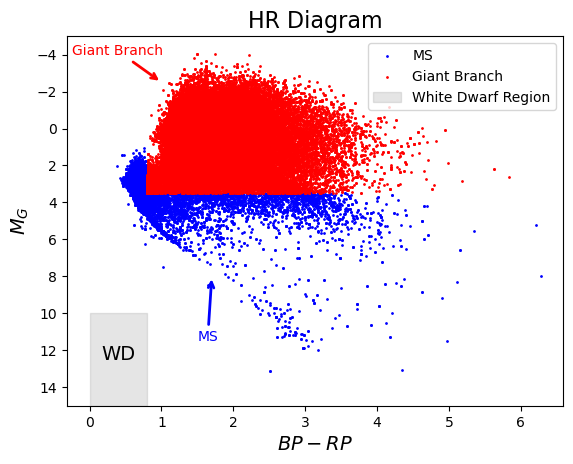

In [9]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Open data

hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data

# Filter out the bad data with a mask

mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)
good_data = data[mask]

# Randomly choose about 80% of the data for plotting the HR diagram

N = len(good_data)
number = int(0.8 * N)
indices = np.random.choice(N, number)
data80 = good_data[indices]

# Compute colour

BP = data80['GAIAEDR3_PHOT_BP_MEAN_MAG']
RP = data80['GAIAEDR3_PHOT_RP_MEAN_MAG']
colour = BP - RP

# Compute absolute magnitude

m_G = data80['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax = data80['GAIAEDR3_PARALLAX']
M_G = m_G + 5 * np.log10(parallax / 1000) + 5

# Classify giant branch and main sequence

giant_branch_mask = (M_G < 3.5) & (colour > 0.8)
ms_mask = ~giant_branch_mask

# Plot everything

plt.scatter(colour[ms_mask], M_G[ms_mask], s=1, color = 'b', label = 'MS')
plt.scatter(colour[giant_branch_mask], M_G[giant_branch_mask], s=1, color = 'r', label = 'Giant Branch')
plt.gca().invert_yaxis()
plt.xlabel(r'$BP - RP$', fontsize = 14)
plt.ylabel(r'$M_G$', fontsize = 14)
plt.title('HR Diagram', fontsize = 16)
plt.fill_betweenx([10, 15], 0, 0.8, color='gray', alpha=0.2, label = 'White Dwarf Region')
plt.annotate('Giant Branch', xy = (1, -2.5), xytext = (-0.25, -4), arrowprops = dict(arrowstyle = '->', color = 'r', lw = 2), color = 'r', fontsize = 10)
plt.annotate('MS', xy = (1.7, 8), xytext = (1.5, 11.5), arrowprops = dict(arrowstyle = '->', color = 'b', lw = 2), color = 'b', fontsize = 10)
plt.text(0.166, 12.5, 'WD', fontsize=14, color = 'k')
plt.legend(loc = 'upper right')
plt.yticks(np.arange(-4, 15, 2))
plt.xticks(np.arange(0, 7, 1))
plt.ylim(15, -5)
plt.show()

In [13]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [14]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 26. Student score: 0.0.  Task Grade = 0.0
